In [1]:
print("OK")

OK


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df=pd.read_csv("wine_data.csv", header=None,usecols=[0,1,2])
df.columns=['Class_label','Alcohol','Malic acid']
df.head()

,Class_label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [18]:
df

,Class_label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [19]:
df.shape

(178, 3)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Class_label  178 non-null    int64  
 1   Alcohol      178 non-null    float64
 2   Malic acid   178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB


In [21]:
df.isnull().sum()

Class_label    0
Alcohol        0
Malic acid     0
dtype: int64

In [35]:
df['Class_label'].value_counts()

Class_label
2    71
1    59
3    48
Name: count, dtype: int64

<Axes: xlabel='Alcohol', ylabel='Density'>

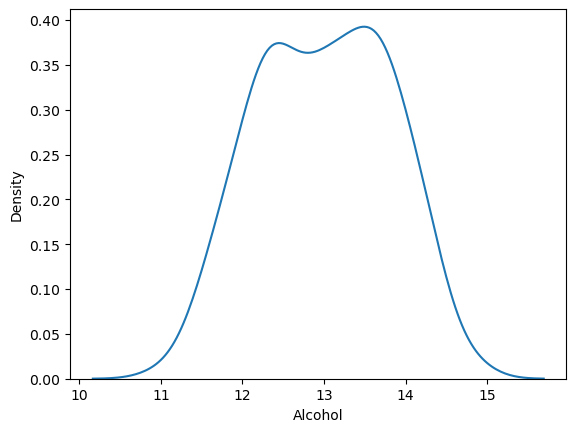

In [22]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

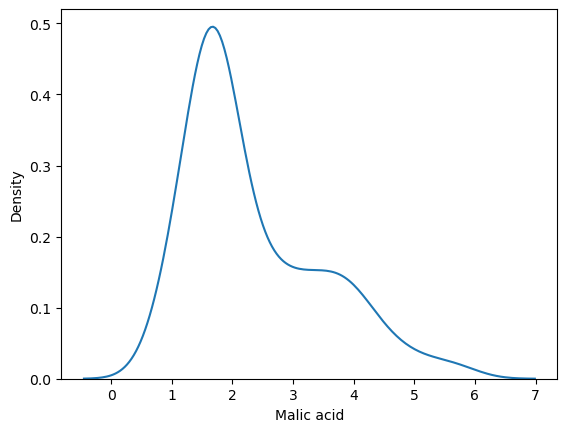

In [23]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

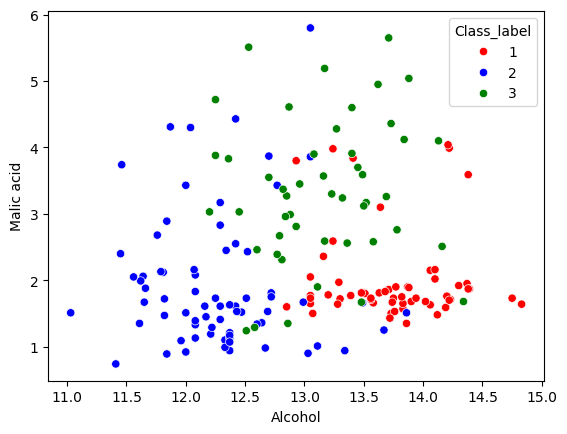

In [ ]:
color_dict={1:'red',3:'Green',2:'blue'}
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic acid'],
    hue=df['Class_label'],
    palette=color_dict


    )

In [ ]:
x=df.drop('Class_label', axis=1)
y=df['Class_label']

x.head()


,Alcohol,Malic acid
0,14.23,1.71
1,13.20,1.78
2,13.16,2.36
3,14.37,1.95
4,13.24,2.59


In [46]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Class_label, dtype: int64

In [52]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)

In [53]:
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [66]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
# fit the scaler to the train set, it will learn parameters
scaler.fit(x_train)
# Transform Train and test sets
x_train_scaler=scaler.transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [67]:
x_train.columns

Index(['Alcohol', 'Malic acid'], dtype='object')

In [69]:
x_train_scaler=pd.DataFrame(x_train_scaler, columns=x_train.columns)
x_test_scaler=pd.DataFrame(x_test_scaler, columns=x_test.columns)


In [75]:
x_test_scaler

,Alcohol,Malic acid
0,0.686842,0.450102
1,0.836842,0.641548
2,0.500000,0.391039
3,0.710526,0.124236
4,0.352632,0.057026
5,0.860526,0.209776
6,0.255263,0.517312
7,0.623684,0.615071
8,0.152632,0.093686
9,0.613158,0.340122


In [72]:
x_train_scaler.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,0.508765,0.308143
std,0.221444,0.224504
min,0.000000,0.000000
25%,0.331579,0.152749
50%,0.503947,0.205703
75%,0.701316,0.464358
max,1.000000,1.000000


In [73]:
np.round(x_train_scaler.describe())

,Alcohol,Malic acid
count,124.0,124.0
mean,1.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,1.0,0.0
75%,1.0,0.0
max,1.0,1.0


In [76]:
x_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.963306,2.402984
std,0.841487,1.102317
min,11.030000,0.890000
25%,12.290000,1.640000
50%,12.945000,1.900000
75%,13.695000,3.170000
max,14.830000,5.800000


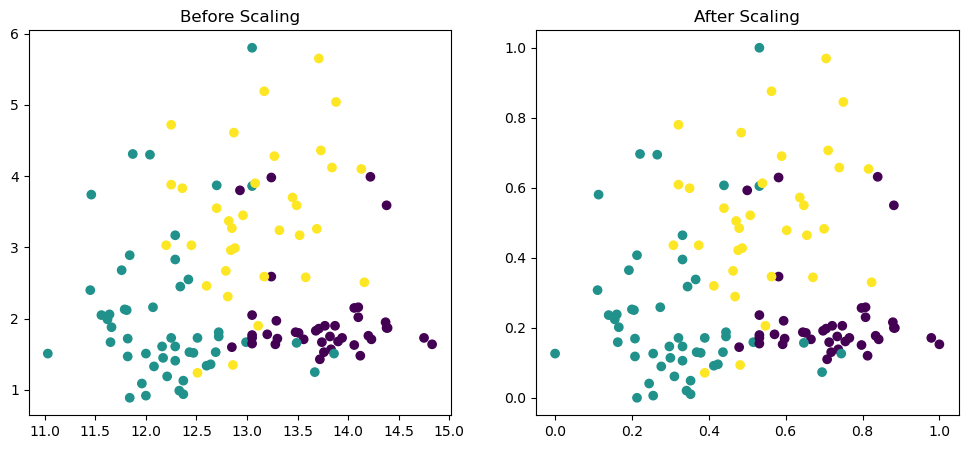

In [92]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(x_train['Alcohol'],x_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaler['Alcohol'],x_train_scaler['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

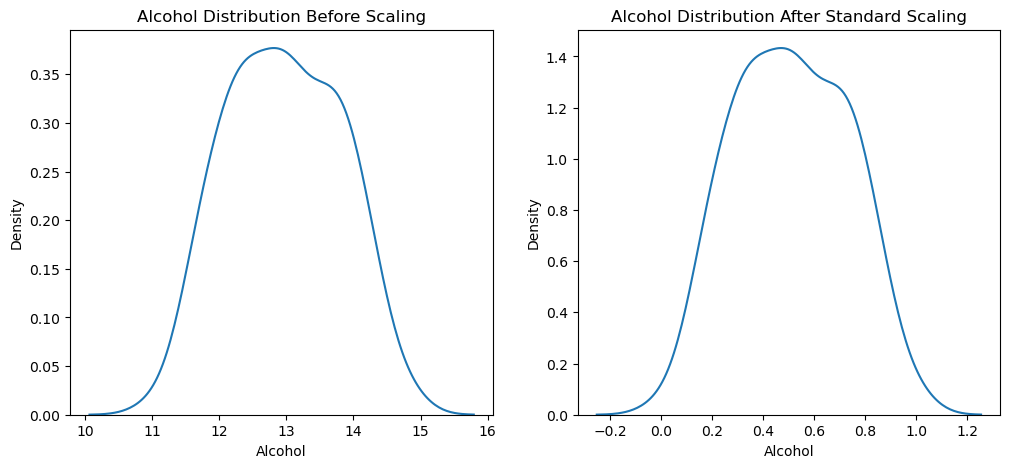

In [77]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(x_train_scaler['Alcohol'], ax=ax2)
plt.show()

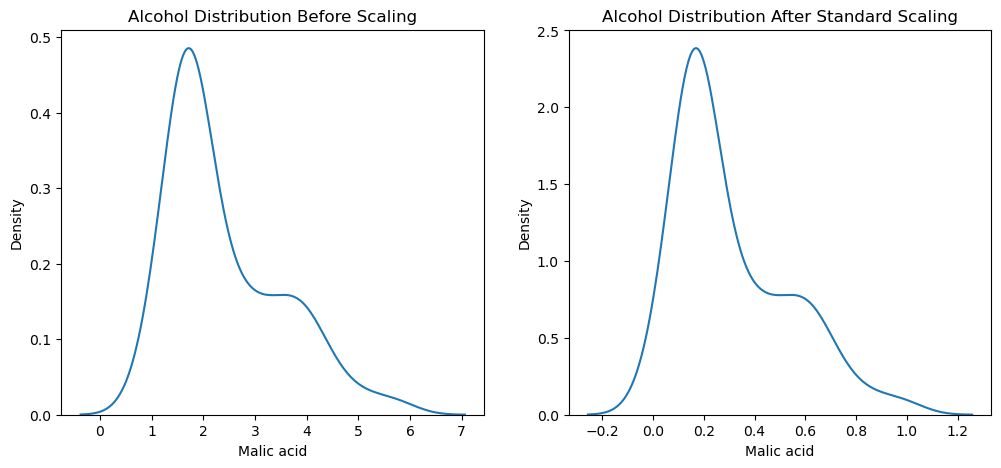

In [93]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(x_train_scaler['Malic acid'], ax=ax2)
plt.show()